In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop

train_dir = pd.read_csv('../input/train.csv')


2026-01-07 04:20:39.250463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767759639.263296      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767759639.267271      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 04:20:39.282875: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
%matplotlib inline


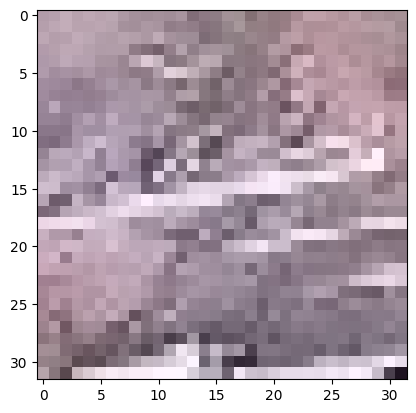

(32, 32, 3)


In [3]:
test_file = train_dir.iloc[100,0]
im = plt.imread('../input/train/train/%s'%test_file)
plt.imshow(im)
plt.show()

print(im.shape)


In [4]:
train_dir.describe()


,has_cactus
count,14175.000000
mean,0.749771
std,0.433160
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [5]:
y_train = train_dir.iloc[:,1].values
X_train = np.zeros((17500,32,32,3))

im_list = train_dir.iloc[:,0]

idx = 0
for fp in im_list:
    image = plt.imread('../input/train/train/%s'%fp)
    X_train[idx,:,:,:] = image
    
    idx+=1


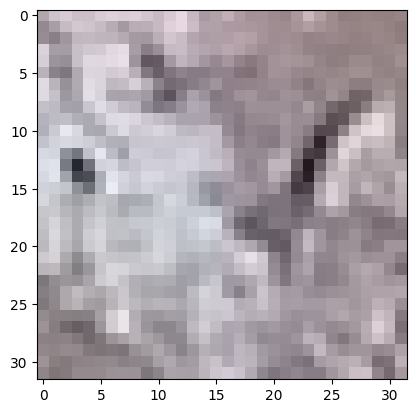

0


In [6]:
plt.imshow(X_train[10,:,:,:]/255)
plt.show()

print(y_train[10])


In [7]:
X_train_scaled = X_train/255


In [8]:
# lets create a convnet

cactus = Sequential()

cactus.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', padding='Same', input_shape=(32,32,3)))
cactus.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', padding='Same'))
cactus.add(MaxPool2D(pool_size=(2,2)))
cactus.add(Dropout(0.2))

cactus.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='Same'))
cactus.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='Same'))
cactus.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
cactus.add(Dropout(0.2))

cactus.add(Flatten())
cactus.add(Dense(256, activation='relu'))
cactus.add(Dropout(0.50))

cactus.add(Dense(1, activation='sigmoid'))

opt = RMSprop(lr=0.001, rho=0.9, epsilon=1e-08, decay=0.0)
lrreduce = ReduceLROnPlateau(monitor='val_acc', patience=3, verbose=1, factor=0.5, min_lr=0.00001)

cactus.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-07 04:20:49.539700: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767759649.540175      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


ValueError: Argument(s) not recognized: {'lr': 0.001}

In [9]:
cactus.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,132,577 (4.32 MB)

 Trainable params: 1,132,577 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
estop = EarlyStopping(patience=3)


In [11]:
cactus.fit(X_train_scaled, y_train,
          validation_split=0.15,
          verbose=True,
          epochs=30,
          batch_size=100,
          callbacks=[lrreduce]
)


NameError: name 'lrreduce' is not defined

In [12]:
import os
fileid = []

def read_in_test(dirstr):
    out_array = np.zeros((4000,32,32,3))
    
    dir_p = os.fsencode(dirstr)
    
    idx=0
    for file in os.listdir(dir_p):
        filename = os.fsdecode(file)
        
        fileid.append(filename)
        
        out_array[idx,:,:,:] = plt.imread('../input/test/test/%s'%filename)
        idx+=1
    
    return out_array/255


In [13]:
X_test = read_in_test('../input/test/test')


IsADirectoryError: [Errno 21] Is a directory: '../input/test/test/test'

In [14]:
out = cactus.predict_proba(X_test)


AttributeError: 'Sequential' object has no attribute 'predict_proba'

In [15]:
out.ravel().shape


NameError: name 'out' is not defined

In [16]:
sub = pd.DataFrame({'id': fileid, 'has_cactus': out.ravel()})
sub['has_cactus'] = sub['has_cactus'].apply(lambda x: 1 if x>0.50 else 0)


NameError: name 'out' is not defined

In [17]:
sub.head()


NameError: name 'sub' is not defined

In [18]:
sub.to_csv('cactus_submission.csv',index=False)


NameError: name 'sub' is not defined